# 03 — Modelagem

Serão comparados cinco classificadores: Regressão Logística, Árvore de Decisão, KNN, SVM linear e Random Forest.

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
PROCESSED = Path("..") / "data" / "processed"
RESULTS = Path("..") / "results"
FIGURES = RESULTS / "figures"
TARGET = "TARGET"

FIGURES.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)

In [19]:
df = pd.read_csv(PROCESSED / "dataset_tratado.csv")
print("Dimensões:", df.shape)
display(df.head())
print("Distribuição do alvo:")
display(df[TARGET].value_counts(normalize=True).rename("proporcao").to_frame())

Dimensões: (36457, 18)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,TARGET
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,32.867899,12.435318,1,0,0,Outros,2.0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,32.867899,12.435318,1,0,0,Outros,2.0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,58.792608,3.104723,0,0,0,Outros,2.0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.320329,8.353183,0,1,1,Sales staff,1.0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,52.320329,8.353183,0,1,1,Sales staff,1.0,0


Distribuição do alvo:


,proporcao
TARGET,
0,0.983103
1,0.016897


## 1. Separando treino e teste

Separei os dados em duas partes: o modelo aprende com a parte de treino e será avaliado na parte de teste, que fica guardada até o final. Mantive a mesma proporção de bons e maus pagadores nas duas partes.

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[TARGET, "ID"])
y = df[TARGET].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
print("Treino:", X_train.shape, "Teste:", X_test.shape)
print("Proporção positiva no treino:", round(y_train.mean(), 4))
print("Proporção positiva no teste:", round(y_test.mean(), 4))

Treino: (25519, 16) Teste: (10938, 16)
Proporção positiva no treino: 0.0169
Proporção positiva no teste: 0.0169


## 2. Preparando os modelos

Cada modelo passa pelas mesmas etapas de preparação: preencher valores vazios, transformar categorias em números e ajustar a escala quando necessário. Essas etapas são repetidas só com os dados usados para treinar cada modelo. Dei mais peso aos poucos exemplos de maus pagadores para que o modelo não se concentre apenas na classe mais comum.

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier

numeric_columns = X_train.select_dtypes(include="number").columns.tolist()
categorical_columns = X_train.select_dtypes(exclude="number").columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_columns),
    ("categorical", categorical_pipeline, categorical_columns),
])

modelos = {
    "Regressão Logística": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
        )),
    ]),
    "Árvore de Decisão": Pipeline([
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            class_weight="balanced", random_state=RANDOM_STATE
        )),
    ]),
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=5, weights="distance", n_jobs=-1)),
    ]),
    "SVM Linear": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LinearSVC(
            class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000
        )),
    ]),
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=150, class_weight="balanced_subsample",
            random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}

## 3. Comparando os modelos

Repeti o treino e a avaliação em três divisões diferentes dos dados de treino. Comparei o F1, que combina precisão e recall, e também mostrei o recall e a balanced accuracy para entender melhor os acertos em cada classe. Os dados de teste continuam guardados para a avaliação final.

,Modelo,Recall médio,F1 médio,Balanced accuracy média
4,Random Forest,0.348,0.290,0.665
1,Árvore de Decisão,0.392,0.284,0.684
2,KNN,0.188,0.257,0.592
3,SVM Linear,0.534,0.044,0.572
0,Regressão Logística,0.534,0.044,0.571


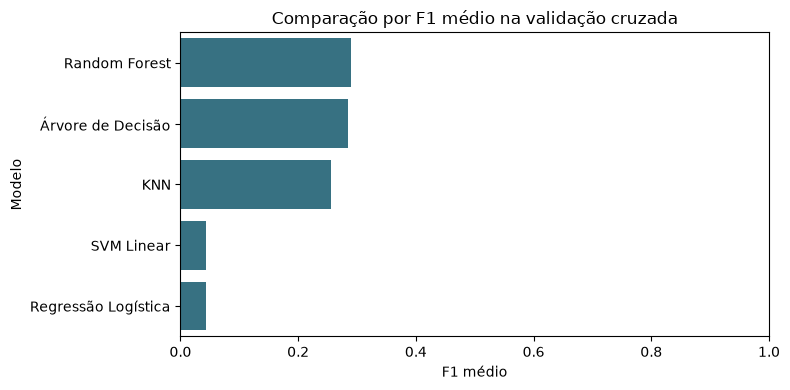

In [22]:
df_resultados = pd.DataFrame(resultados).sort_values("F1 médio", ascending=False)
display(df_resultados.round(3))
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=df_resultados, x="F1 médio", y="Modelo", color="#2a788e", ax=ax)
ax.set_xlim(0, 1)
ax.set_title("Comparação por F1 médio na validação cruzada")
fig.tight_layout()
fig.savefig(FIGURES / "05_comparacao_modelos.png", dpi=160, bbox_inches="tight")
plt.show()

## 4. Resultado da comparação

A Random Forest teve o maior F1 médio (0,290), seguida de perto pela Árvore de Decisão (0,284). A árvore encontrou uma parte um pouco maior dos maus pagadores (recall de 0,392 contra 0,348). O KNN ficou com F1 de 0,257. A SVM linear e a Regressão Logística tiveram recall maior (0,534), mas F1 bem menor (0,044), porque também marcaram muitos bons pagadores como maus. Escolhi a Random Forest pelo equilíbrio entre essas medidas e treinei-a com todos os dados de treino.

In [23]:
best_model_name = df_resultados.iloc[0]["Modelo"]
best_model = modelos[best_model_name]
best_model.fit(X_train, y_train)

MODEL_DIR = Path("..") / "results" / "models"
METRICS_DIR = Path("..") / "results" / "metrics"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

import joblib

joblib.dump(best_model, MODEL_DIR / "best_model.joblib")
df_resultados.to_csv(METRICS_DIR / "validacao_cruzada.csv", index=False)
print(f"Modelo selecionado: {best_model_name}")
print(f"Artefato salvo em: {MODEL_DIR / 'best_model.joblib'}")

Modelo selecionado: Random Forest
Artefato salvo em: ..\results\models\best_model.joblib
